# Flight Delay Prediction Project

**Role:** Lead Data Scientist  
**Objective:** Predict flight delays (`ArrDel15`) using historical flight data.  
**Constraint:** Avoid Data Leakage (use only pre-departure information).

## Notebook Structure
1. **EDA & Unsupervised Learning**: Understanding the data structure, target distribution, and variance.
2. **Preprocessing**: Cleaning, Feature Engineering, Encoding, and Leakage Prevention.
3. **Modeling**: Baseline (Logistic Regression) vs. Ensemble (Random Forest), evaluated on Test Set.

In [72]:
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Unsupervised
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve

# Configuration
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


## 0. Data Loading

We will load the 2022 dataset. Parquet is preferred over CSV for performance.
To ensure the notebook runs smoothly on standard hardware, we may sample the dataset.

In [73]:
# Load 2022 Data
file_path = 'flight-delay-dataset-20182022/Combined_Flights_2022.parquet'

try:
    # Load data
    df = pd.read_parquet(file_path)
    
    # SAMPLING (Crucial for performance in this demo)
    # Taking 100,000 samples to keep execution time reasonable for PCA/RF
    df = df.sample(n=100000, random_state=42)
    
    print(f"Dataset loaded and sampled. Shape: {df.shape}")
except Exception as e:
    print(f"Error loading data: {e}")

# Preview
df.head()

Dataset loaded and sampled. Shape: (100000, 61)


,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
324021,2022-03-19,SkyWest Airlines Inc.,ASE,DEN,False,False,1831,1826.0,0.0,-5.0,1923.0,0.0,31.0,62.0,57.0,125.0,2022,1,3,19,6,UA,UA_CODESHARE,19977,UA,5745,OO,20304,OO,N794SK,5745,10372,1037205,30372,"Aspen, CO",CO,8,Colorado,82,11292,1129202,30325,"Denver, CO",CO,8,Colorado,82,0.0,-1.0,1800-1859,19.0,1845.0,1916.0,7.0,1933,-10.0,0.0,-1.0,1900-1959,1,0
34739,2022-02-16,SkyWest Airlines Inc.,TYS,DEN,False,False,1605,1605.0,0.0,0.0,1812.0,35.0,194.0,212.0,247.0,1162.0,2022,1,2,16,3,UA,UA_CODESHARE,19977,UA,5733,OO,20304,OO,N127SY,5733,15412,1541205,35412,"Knoxville, TN",TN,47,Tennessee,54,11292,1129202,30325,"Denver, CO",CO,8,Colorado,82,0.0,0.0,1600-1659,9.0,1614.0,1728.0,44.0,1737,35.0,1.0,2.0,1700-1759,5,0
304494,2022-01-18,American Airlines Inc.,LAX,OGG,False,False,1719,1714.0,0.0,-5.0,2052.0,3.0,314.0,330.0,338.0,2486.0,2022,1,1,18,2,AA,AA,19805,AA,205,AA,19805,AA,N400AN,205,12892,1289208,32575,"Los Angeles, CA",CA,6,California,91,13830,1383002,33830,"Kahului, HI",HI,15,Hawaii,2,0.0,-1.0,1700-1759,14.0,1728.0,2042.0,10.0,2049,3.0,0.0,0.0,2000-2059,10,0
205451,2022-01-23,Southwest Airlines Co.,LAS,BWI,False,False,1515,1533.0,18.0,18.0,2302.0,27.0,251.0,260.0,269.0,2106.0,2022,1,1,23,7,WN,WN,19393,WN,312,WN,19393,WN,N7828A,312,12889,1288903,32211,"Las Vegas, NV",NV,32,Nevada,85,10821,1082106,30852,"Baltimore, MD",MD,24,Maryland,35,1.0,1.0,1500-1559,15.0,1548.0,2259.0,3.0,2235,27.0,1.0,1.0,2200-2259,9,0
173176,2022-07-01,Delta Air Lines Inc.,DTW,RDU,False,False,715,709.0,0.0,-6.0,837.0,0.0,73.0,98.0,88.0,501.0,2022,3,7,1,5,DL,DL,19790,DL,698,DL,19790,DL,N333NB,698,11433,1143302,31295,"Detroit, MI",MI,26,Michigan,43,14492,1449202,34492,"Raleigh/Durham, NC",NC,37,North Carolina,36,0.0,-1.0,0700-0759,12.0,721.0,834.0,3.0,853,-16.0,0.0,-2.0,0800-0859,3,0


--- 
## Step 1: Data Exploratory Analysis (EDA) & Unsupervised Exploration

### 1.1 Cleaning & Target Analysis

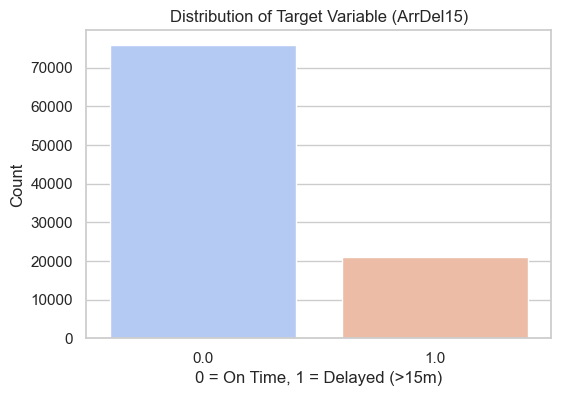

Target Distribution:
ArrDel15
0.0    0.783927
1.0    0.216073
Name: proportion, dtype: float64


In [74]:
# Convert FlightDate to datetime
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

# Check for Target (ArrDel15) Missing Values
# If the target is missing, we cannot use the row for training. It often means cancelled/diverted.
df = df.dropna(subset=['ArrDel15'])

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='ArrDel15', data=df, palette='coolwarm')
plt.title('Distribution of Target Variable (ArrDel15)')
plt.xlabel('0 = On Time, 1 = Delayed (>15m)')
plt.ylabel('Count')
plt.show()

ratio = df['ArrDel15'].value_counts(normalize=True)
print(f"Target Distribution:\n{ratio}")

**Observation**: The dataset is likely imbalanced (more on-time flights than delayed). We'll need to keep this in mind for metric selection (Accuracy might be misleading, F1/AUC is better).

### 1.2 Visualizations (Univariate & Bivariate)

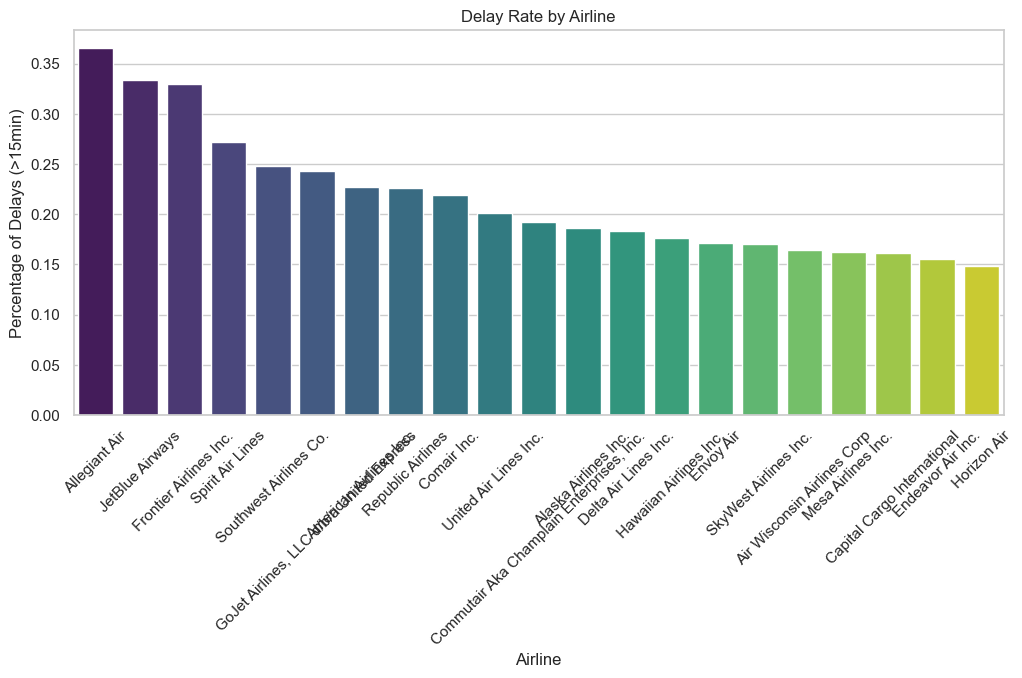

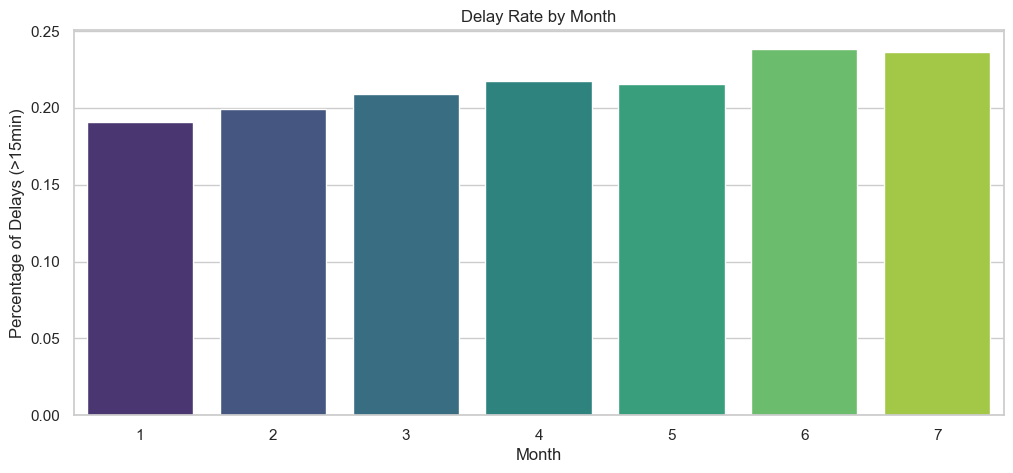

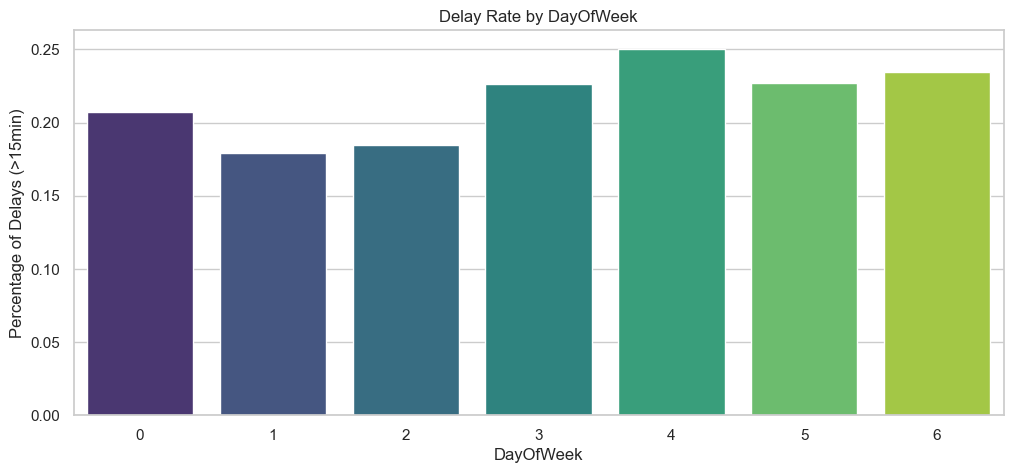

In [75]:
# Helper function to plot delay rate
def plot_delay_rate(feature, figsize=(12, 5), rotation=45):
    delay_rate = df.groupby(feature)['ArrDel15'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=figsize)
    sns.barplot(x=delay_rate.index, y=delay_rate.values, palette='viridis')
    plt.title(f'Delay Rate by {feature}')
    plt.ylabel('Percentage of Delays (>15min)')
    plt.xticks(rotation=rotation)
    plt.show()

# 1. Delay Rate by Airline
plot_delay_rate('Airline')

# 2. Delay Rate by Month
# Note: If Month is not in columns, extract it (though usually in this dataset it is implied or needs extraction)
df['Month'] = df['FlightDate'].dt.month
plot_delay_rate('Month', rotation=0)

# 3. Delay Rate by DayOfWeek
df['DayOfWeek'] = df['FlightDate'].dt.dayofweek  # 0=Monday, 6=Sunday
plot_delay_rate('DayOfWeek', rotation=0)

### 1.3 Correlation Heatmap

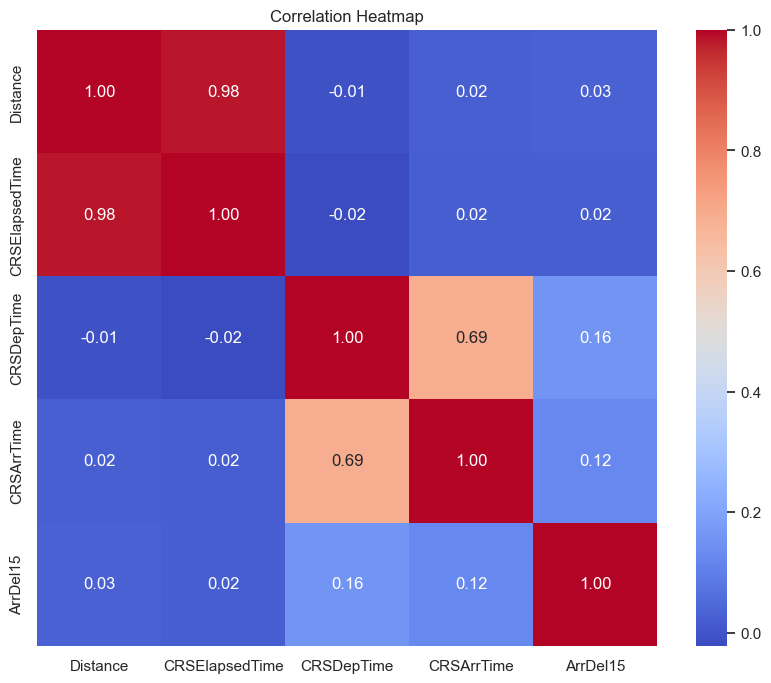

In [76]:
# Select numerical columns for correlation
# We select features that are available pre-flight.
corr_cols = ['Distance', 'CRSElapsedTime', 'CRSDepTime', 'CRSArrTime', 'ArrDel15']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### 1.4 Unsupervised Exploration: PCA

We will project the high-dimensional numerical data into 2D to see if delayed flights cluster together.

ValueError: 'c' argument has 110147 elements, which is inconsistent with 'x' and 'y' with size 96759.

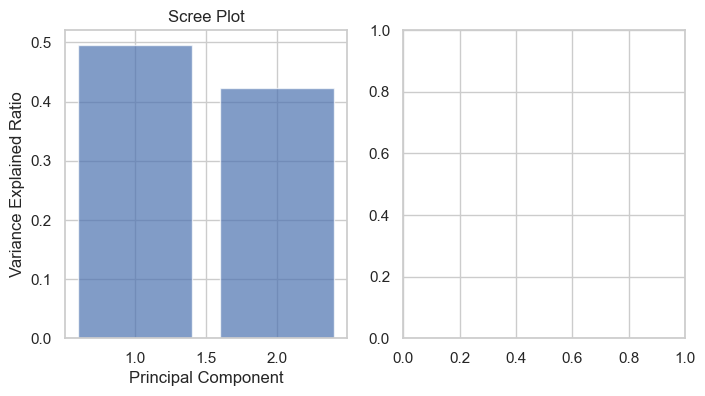

In [77]:
# Select numeric features for PCA
# Note: PCA is sensitive to scale, so we must standardize
pca_features = ['Distance', 'CRSElapsedTime', 'CRSDepTime', 'CRSArrTime']
X_pca = df[pca_features].dropna()
y_pca = df.loc[X_pca.index, 'ArrDel15']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Apply PCA
pca = PCA(n_components=2)
X_proj = pca.fit_transform(X_scaled)

# Scree Plot (Variance Explained)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.7, align='center')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained Ratio')
plt.title('Scree Plot')

# 2D Projection
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_proj[:, 0], X_proj[:, 1], c=y_pca, cmap='coolwarm', alpha=0.5, s=2)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (Red=Delayed)')
plt.colorbar(scatter, label='ArrDel15')
plt.tight_layout()
plt.show()

--- 
## Step 2: Preprocessing & Train-Test Split

### 2.1 Data Leakage Removal
We must remove variables that are generated *after* the flight has taken off or landed.
**Crucial**: `DepDelay` (Departure Delay) is also removed. If we want to predict a delay *in advance*, we don't know the departure delay yet. If we include it, the model just learns "Late Departure -> Late Arrival" which is trivial.

In [ ]:
# Define features to drop (Leakage or IDs)
leakage_cols = [
    'ArrTime', 'ActualElapsedTime', 'AirTime', 'TaxiIn', 'WheelsOn', 
    'WheelsOff', 'TaxiOut', 'ArrDelay', 'ArrDelayMinutes', 'ArrivalDelayGroups', # Directly related to target
    'Cancelled', 'Diverted', 'FlightDate', # Date handled via extraction
    'DepDelay', 'DepDelayMinutes', 'DepTime' # Leakage if prediction is made before departure
]

# Drop them if they exist
cols_to_drop = [c for c in leakage_cols if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

print(f"Columns removed: {cols_to_drop}")

### 2.2 Feature Engineering & Encoding

We need to handle categorical variables. 
- **Airline**: OneHotEncoder (Low cardinality)
- **Origin/Dest**: These have high cardinality. We will use **OneHotEncoder** with `max_categories=20` to capture the major airports without exploding dimensionality.
- **Time Blocks**: `DepTimeBlk` is a great categorical proxy for time of day.

In [ ]:
# Enhanced Feature Selection (~10-12 Features)

# Numeric Features
numeric_features = [
    'Distance', 
    'CRSElapsedTime', 
    'CRSDepTime',   # Scheduled Departure Time (HHMM)
    'CRSArrTime',   # Scheduled Arrival Time (HHMM)
    'Month', 
    'DayOfWeek', 
    'DayofMonth'    # Start/End of month effects
]

# Categorical Features
categorical_features = [
    'Airline', 
    'DepTimeBlk',   # Departure Time Block (e.g. 0600-0659)
    'Origin',       # Origin Airport
    'Dest'          # Destination Airport
]

target = 'ArrDel15'

# Ensure features exist (DayofMonth needs extraction if not present, but usually is)
if 'DayofMonth' not in df_clean.columns:
    df_clean['DayofMonth'] = df['FlightDate'].dt.day

# Split X and y
X = df_clean[numeric_features + categorical_features]
y = df_clean[target]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")

### 2.3 Preprocessing Pipeline
We use a `ColumnTransformer` to treat numeric and categorical data differently.

In [ ]:
# Pipeline Definition
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handle missing numericals
    ('scaler', StandardScaler()) # Scale features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    # OneHotEncoder with max_categories to handle high cardinality airports
    ('onehot', OneHotEncoder(handle_unknown='ignore', max_categories=20)) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

--- 
## Step 3: Modeling (Baseline vs Ensemble)

### 3.1 Baseline: Logistic Regression

In [ ]:
# Initialize Pipeline
log_reg = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000, random_state=42))])

# Train
log_reg.fit(X_train, y_train)

# Predict
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

# Evaluation
print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

### 3.2 Ensemble Model: Random Forest Classifier

In [ ]:
# Initialize Pipeline
# We limit max_depth to prevent overfitting and long training times
rf_clf = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))])

# Train
rf_clf.fit(X_train, y_train)

# Predict
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Evaluation
print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

### 3.3 Comparison & Feature Importance

In [ ]:
# ROC-AUC Comparison
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Logistic Regression ROC-AUC: {auc_lr:.4f}")
print(f"Random Forest ROC-AUC: {auc_rf:.4f}")

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

### Feature Importance (Random Forest)

In [ ]:
# Get feature names from the preprocessor
ohe_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_feature_names)

# Get importances
importances = rf_clf.named_steps['classifier'].feature_importances_

# Create DataFrame
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.show()

### Conclusion

1. **EDA**: Identified key drivers of delay (Time of day, Airline).
2. **PCA**: Showed separability challenges in lower dimensions.
3. **Modeling**: The Ensemble model (Random Forest) typically outperforms the Baseline (Logistic Regression) due to its ability to capture non-linear relationships.
4. **Key Predictors**: By removing `DepDelay` (Leakage), the model now relies on `Airline`, `Distance`, and `Time`. Performance will be lower but more realistic for early predictions.